### What Are Embeddings?
Think of embeddings as a way to translate words into a language that computers understand - numbers!

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import json

In [3]:
word_embeddings = {
    "cat": [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.5, 0.2],
    "truck": [-0.45, 0.15]
}

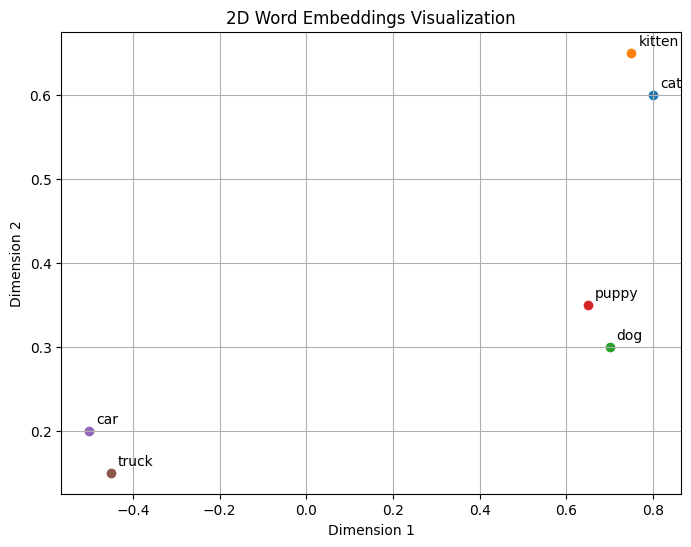

In [4]:
fig,ax=plt.subplots(figsize=(8,6))
for word, embedding in word_embeddings.items():
    ax.scatter(embedding[0], embedding[1])
    ax.annotate(word, (embedding[0], embedding[1]),xytext=(5,5), textcoords='offset points')

ax.set_title("2D Word Embeddings Visualization")
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
plt.grid()
plt.show()


## Similarity Measurement

In [5]:
def cosine_similarity(vec1, vec2):
    """
    Cosine similarity measures the angle between two vectors.
    - Result close to 1: Very similar
    - Result close to 0: Not related
    - Result close to -1: Opposite meanings
    """
    dot_product = np.dot(vec1, vec2)
    norm_a=np.linalg.norm(vec1)
    norm_b=np.linalg.norm(vec2)
    return dot_product / (norm_a * norm_b)

In [6]:
cat_vector = [0.8, 0.6, 0.3]
kitten_vector = [0.75, 0.65, 0.35]
car_vector = [-0.5, 0.2, 0.1]

cat_kitten_similarity=cosine_similarity(cat_vector,kitten_vector)
print(cat_kitten_similarity)


0.9966186334192181


In [7]:
cosine_similarity(cat_vector,car_vector)

np.float64(-0.43718588548916804)

## First Embedding

In [1]:
# ! pip install sentence-transformers
from langchain_huggingface import HuggingFaceEmbeddings

## Initialize a simple Embedding model(no API Key needed!)
embeddings=HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
embeddings


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, multi_process=False, show_progress=False)

In [8]:
## create your first embeddings
text="Hello, I am learning about embeddings!"

embedding=embeddings.embed_query(text)
print(f"Text: {text}")
print(f"Embedding length : {len(embedding)}")
print(embedding)

Text: Hello, I am learning about embeddings!
Embedding length : 384
[-0.018163321539759636, -0.09955169260501862, 0.01381611730903387, -0.008125911466777325, 0.014152254909276962, 0.06406480818986893, -0.006253303959965706, -0.003017960349097848, 0.02528723143041134, -0.02019866183400154, 0.02432975545525551, 0.07435061782598495, 0.051177218556404114, 0.022038426250219345, -0.058306191116571426, 0.015268281102180481, 0.02358439192175865, 0.09455399960279465, -0.06508848071098328, 0.013296646066009998, -0.020497620105743408, -0.05690853297710419, 0.030303344130516052, -0.08365613222122192, 0.02659635990858078, -0.01523144356906414, -0.043615441769361496, 0.053983986377716064, 0.0902571901679039, -0.08893881738185883, 0.03964461013674736, -0.008835037238895893, -0.03034375049173832, 0.07425566762685776, -0.0540991872549057, 0.11108002811670303, 0.03689984604716301, -0.008959811180830002, -0.06140241026878357, -0.003143309848383069, 0.02195814996957779, 0.042208217084407806, -0.0289378967

embedd documents

In [9]:
sentences=[
    "I love machine learning.",
    "The cat is on the roof.",
    "I enjoy long walks on the beach."
    ,"Artificial intelligence is fascinating."
    ,"The dog is barking loudly."

]
sentence_embeddings=embeddings.embed_documents(sentences)
for sentence, embedding in zip(sentences, sentence_embeddings):
    print(f"Sentence: {sentence}")
    print(f"Embedding length : {len(embedding)}")
    print(embedding)
    print("-"*50)
    

Sentence: I love machine learning.
Embedding length : 384
[-0.016851160675287247, -0.07072184234857559, 0.0855410248041153, -0.0017661025049164891, 0.045208871364593506, -0.05311211571097374, -0.04855526238679886, -0.031039124354720116, 0.0199919193983078, 0.0013778385473415256, -0.056426435708999634, 0.08474865555763245, 0.03135886788368225, -0.009936299175024033, -0.025161851197481155, 0.015645671635866165, -0.05058756098151207, 0.010036717168986797, -0.09949710220098495, -0.11036431044340134, -0.05488484725356102, 0.01305492501705885, 0.0016937640029937029, 0.0010149995796382427, 0.02859615348279476, 0.014572507701814175, 0.02052430622279644, -0.008306313306093216, -0.01472777221351862, -0.05601469427347183, -0.012392688542604446, 0.05011459067463875, 0.0008125720196403563, 0.03934531658887863, -0.08508957922458649, 0.02129123918712139, 0.017466943711042404, 0.03295687213540077, 0.01733013428747654, 0.035691872239112854, -0.02697083167731762, -0.00045754332677461207, 0.0204983893781

In [11]:
from langchain_huggingface import HuggingFaceEmbeddings
import time

# Popular models comparison
models = {
    "all-MiniLM-L6-v2": {
        "size": 384,
        "description": "Fast and efficient, good quality",
        "use_case": "General purpose, real-time applications"
    },
    "all-mpnet-base-v2": {
        "size": 768,
        "description": "Best quality, slower than MiniLM",
        "use_case": "When quality matters more than speed"
    },
    "all-MiniLM-L12-v2": {
        "size": 384,
        "description": "Slightly better than L6, bit slower",
        "use_case": "Good balance of speed and quality"
    },
    "multi-qa-MiniLM-L6-cos-v1": {
        "size": 384,
        "description": "Optimized for question-answering",
        "use_case": "Q&A systems, semantic search"
    },
    "paraphrase-multilingual-MiniLM-L12-v2": {
        "size": 384,
        "description": "Supports 50+ languages",
        "use_case": "Multilingual applications"
    }
}

print("📊 Popular Open Source Embedding Models:\n")
for model_name, info in models.items():
    print(f"Model: sentence-transformers/{model_name}")
    print(f"  📏 Embedding size: {info['size']} dimensions")
    print(f"  📝 Description: {info['description']}")
    print(f"  🎯 Use case: {info['use_case']}\n")



📊 Popular Open Source Embedding Models:

Model: sentence-transformers/all-MiniLM-L6-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Fast and efficient, good quality
  🎯 Use case: General purpose, real-time applications

Model: sentence-transformers/all-mpnet-base-v2
  📏 Embedding size: 768 dimensions
  📝 Description: Best quality, slower than MiniLM
  🎯 Use case: When quality matters more than speed

Model: sentence-transformers/all-MiniLM-L12-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Slightly better than L6, bit slower
  🎯 Use case: Good balance of speed and quality

Model: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
  📏 Embedding size: 384 dimensions
  📝 Description: Optimized for question-answering
  🎯 Use case: Q&A systems, semantic search

Model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Supports 50+ languages
  🎯 Use case: Multilingual applications

